### Wstępna analiza na podstawie jednego miesiąca przejazdów żółtych taksówek

Sprawdzamy jakie są kolumny, co one oznaczają, które są zbędne, a które zawierają wiele wartości NA itd. 

In [2]:
import pandas as pd

file_path = "../data/raw/yellow_tripdata_2026-03.parquet"

# 2. Wczytujemy dane
df = pd.read_parquet(file_path)

# 3. Wyświetlamy pierwsze 5 wierszy
print("--- PODGLĄD DANYCH (HEAD) ---")
display(df.head())

# 4. Wypisujemy wszystkie kolumny
print("\n--- LISTA WSZYSTKICH KOLUMN ---")
for col in df.columns:
    print(f"- {col}")

# 5. Podstawowe informacje o typach i brakujących wartościach
print("\n--- INFORMACJE O RAMCE DANYCH ---")
df.info()

--- PODGLĄD DANYCH (HEAD) ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-03-01 00:02:26,2026-03-01 00:13:45,1.0,2.58,1.0,N,48,151,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
1,2,2026-03-01 00:19:33,2026-03-01 00:28:21,1.0,1.50,1.0,N,238,166,1,10.0,1.0,0.5,0.00,0.0,1.0,15.00,2.5,0.0,0.00
2,2,2026-03-01 00:07:20,2026-03-01 00:15:12,2.0,0.88,1.0,N,90,249,1,8.6,1.0,0.5,2.87,0.0,1.0,17.22,2.5,0.0,0.75
3,2,2026-03-01 00:16:11,2026-03-01 00:28:20,1.0,1.76,1.0,N,249,137,1,12.1,1.0,0.5,3.57,0.0,1.0,21.42,2.5,0.0,0.75
4,2,2026-03-01 00:20:47,2026-03-01 00:30:44,2.0,1.57,1.0,N,100,142,1,11.4,1.0,0.5,3.43,0.0,1.0,20.58,2.5,0.0,0.75



--- LISTA WSZYSTKICH KOLUMN ---
- VendorID
- tpep_pickup_datetime
- tpep_dropoff_datetime
- passenger_count
- trip_distance
- RatecodeID
- store_and_fwd_flag
- PULocationID
- DOLocationID
- payment_type
- fare_amount
- extra
- mta_tax
- tip_amount
- tolls_amount
- improvement_surcharge
- total_amount
- congestion_surcharge
- Airport_fee
- cbd_congestion_fee

--- INFORMACJE O RAMCE DANYCH ---
<class 'pandas.DataFrame'>
RangeIndex: 3952451 entries, 0 to 3952450
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           i

### Wstępna cech i proponowana konwersja typów

| Nazwa kolumny | Typ pierwotny | Status | Typ docelowy | Uzasadnienie techniczne |
| --- | --- | --- | --- | --- |
| **VendorID** | int32 | **Odrzucono** | - | Dane techniczne dostawcy, brak wpływu na charakterystykę kursu. |
| **tpep_pickup_datetime** | datetime64[us] | **Uwzględniono** | datetime64[ns] | Podstawa analizy czasu, pory dnia i dnia tygodnia. |
| **tpep_dropoff_datetime** | datetime64[us] | **Uwzględniono** | datetime64[ns] | Wykorzystywana do obliczenia czasu trwania przejazdu. |
| **passenger_count** | float64 | **Uwzględniono** | int8 | Mała wartość całkowita; drastyczna redukcja zużycia pamięci. |
| **trip_distance** | float64 | **Uwzględniono** | float32 | Dystans w milach; precyzja pojedyncza jest wystarczająca. |
| **RatecodeID** | float64 | **Uwzględniono** | int8 | Kod taryfy (1-6); zamiana na typ całkowitoliczbowy. |
| **store_and_fwd_flag** | str | **Odrzucono** | - | Flaga techniczna przesyłu danych; nieistotna dla analizy wzorców. |
| **PULocationID** | int32 | **Uwzględniono** | int16 | ID strefy (1-263); typ `int16` optymalizuje zakres danych. |
| **DOLocationID** | int32 | **Uwzględniono** | int16 | ID strefy docelowej; spójność z lokalizacją startową. |
| **payment_type** | int64 | **Uwzględniono** | int8 | Typ płatności (kategorie 1-4); minimalne zapotrzebowanie na pamięć. |
| **fare_amount** | float64 | **Uwzględniono** | float32 | Podstawowa składowa kosztu przejazdu. |
| **extra** | float64 | **Odrzucono** | - | Opłaty dodatkowe o niskim wpływie na ogólną typologię. |
| **mta_tax** | float64 | **Odrzucono** | - | Podatek o stałej wartości; brak istotnej zmienności w danych. |
| **tip_amount** | float64 | **Uwzględniono** | float32 | Napiwek; istotny parametr w analizie nietypowych transakcji. |
| **tolls_amount** | float64 | **Uwzględniono** | float32 | Opłaty drogowe; różnicuje trasy (np. mosty/tunele). |
| **improvement_surcharge** | float64 | **Odrzucono** | - | Stała opłata techniczna; brak wartości analitycznej. |
| **total_amount** | float64 | **Uwzględniono** | float32 | Całkowita kwota transakcji do analizy finansowej. |
| **congestion_surcharge** | float64 | **Uwzględniono** | float32 | Wskaźnik wjazdu do stref o dużym natężeniu ruchu. |
| **Airport_fee** | float64 | **Uwzględniono** | float32 | Pozwala na szybką separację kursów lotniskowych. |
| **cbd_congestion_fee** | float64 | **Odrzucono** | - | Dubluje informację z opłaty `congestion_surcharge`. |

---

Wybór mniejszych typów danych (np. `int8` zamiast `float64` dla liczby pasażerów) oraz usunięcie kolumn o charakterze stałym lub czysto technicznym pozwoli na sprawniejsze przetwarzanie danych w algorytmach **PCA** oraz **UMAP**, zachowując przy tym pełną zdolność do wykrywania anomalii.


In [3]:
# Pomiar początkowego zużycia pamięci (konwersja z bajtów na MB)
initial_memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

# Definicja kolumn do zachowania
columns_to_keep = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'passenger_count',
    'trip_distance',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'fare_amount',
    'tip_amount',
    'tolls_amount',
    'total_amount',
    'congestion_surcharge',
    'Airport_fee'
]

# Filtrowanie ramki danych
df = df[columns_to_keep]

# Oczyszczenie z wartości brakujących przed konwersją typów
columns_with_nan = ['passenger_count', 'RatecodeID', 'payment_type', 'congestion_surcharge', 'Airport_fee']
df = df.dropna(subset=columns_with_nan)

# Słownik mapowania docelowych typów danych
target_dtypes = {
    'passenger_count': 'int8',
    'trip_distance': 'float32',
    'RatecodeID': 'int8',
    'PULocationID': 'int16',
    'DOLocationID': 'int16',
    'payment_type': 'int8',
    'fare_amount': 'float32',
    'tip_amount': 'float32',
    'tolls_amount': 'float32',
    'total_amount': 'float32',
    'congestion_surcharge': 'float32',
    'Airport_fee': 'float32'
}

# Wykonanie konwersji typów numerycznych
df = df.astype(target_dtypes)

# Konwersja znaczników czasu na format nanosekundowy [ns]
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')
df = df.dropna(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])

# Pomiar końcowego zużycia pamięci
final_memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

# Obliczenie procentowej redukcji
memory_reduction_pct = ((initial_memory_mb - final_memory_mb) / initial_memory_mb) * 100

# Wyświetlenie raportu
print("=========================================")
print("       RAPORT OPTYMALIZACJI PAMIĘCI      ")
print("=========================================")
print(f"Początkowy rozmiar DataFrame: {initial_memory_mb:.2f} MB")
print(f"Końcowy rozmiar DataFrame:    {final_memory_mb:.2f} MB")
print(f"Redukcja zużycia pamięci:     {memory_reduction_pct:.2f}%")
print("=========================================")

       RAPORT OPTYMALIZACJI PAMIĘCI      
Początkowy rozmiar DataFrame: 560.95 MB
Końcowy rozmiar DataFrame:    146.24 MB
Redukcja zużycia pamięci:     73.93%


## Preprocessing

### Inżynieria cech:
- wyliczenie czasu trwania kursu (na podstawie jego rozpoczęcia i zakończenia)
- przekształcenie godziny na wartość liczbową (0-23)
- oznaczenie numeryczne dnia tygodnia

### Usunięcie błędnych danych:
- kursy trwające mniej niż minutę lub więcej niż 6h
- przejazdy, gdzie dystans wynosi 0 mil
- ujemne lub zerowe wartości opłat


### ID Stref:
Zamiana dokładnych obszarów na dzielnice i zastosowanie One-Hot-Encoding

### Skalowanie i standaryzacja danych:
Niezbędne dla algorytmów redukcji wielowymiarowości


### Pobranie reprezentatywnej próbki danych:
DataFrame zawiera ok 3 miliony wierszy, co jest zdecydowanie zbyt wielką próbą dla algorytmów typu UMAP, t-SNE. Należy wykonać próbkowanie statystyczne, by ograniczyć analizę do 20-30 k rekordów.

In [4]:
# Obliczenie czasu trwania kursu w minutach
# Różnicę czasu konwertujemy na sekundy, a następnie dzielimy przez 60
df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60.0
df['duration'] = df['duration'].astype('float32')

# Przekształcenie godziny rozpoczęcia kursu na wartość liczbową (0-23)
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour.astype('int8')

# Oznaczenie numeryczne dnia tygodnia (0 = Poniedziałek, 6 = Niedziela)
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek.astype('int8')

# Podgląd efektów inżynierii cech
print("--- PODGLĄD WYEKSTRAHOWANYCH CECH ---")
display(df[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'duration', 'pickup_hour', 'pickup_day_of_week']].head())


# W przyszłości nie będziemy uwzględniać tpep_pickup_datetime i dropoff datetime w np. PCA, ale przydadzą się do pogłębionej analizy
# Przykład: df zachowuje daty, ale do modeli przekazujemy tylko liczby
# X = df.drop(columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])

--- PODGLĄD WYEKSTRAHOWANYCH CECH ---


,tpep_pickup_datetime,tpep_dropoff_datetime,duration,pickup_hour,pickup_day_of_week
0,2026-03-01 00:02:26,2026-03-01 00:13:45,11.316667,0,6
1,2026-03-01 00:19:33,2026-03-01 00:28:21,8.800000,0,6
2,2026-03-01 00:07:20,2026-03-01 00:15:12,7.866667,0,6
3,2026-03-01 00:16:11,2026-03-01 00:28:20,12.150000,0,6
4,2026-03-01 00:20:47,2026-03-01 00:30:44,9.950000,0,6


In [5]:
#Zapisujemy początkową liczbę wierszy
rows_before = len(df)

# Definiujemy maski logiczne dla poprawnych danych
# Czas trwania: od 1 minuty do 360 minut (6 godzin)
correct_duration = (df['duration'] >= 1.0) & (df['duration'] <= 360.0)

# Dystans: większy niż 0 mil
correct_distance = df['trip_distance'] > 0.0

# Opłaty: podstawowa oraz całkowita muszą być większe niż 0
correct_fare = df['fare_amount'] > 0.0
correct_total = df['total_amount'] > 0.0

# Zastosowanie filtrów (zostawiamy tylko rekordy spełniające wszystkie warunki)
df = df[correct_duration & correct_distance & correct_fare & correct_total]

# Obliczenie statystyk operacji
rows_after = len(df)
rows_removed = rows_before - rows_after
pct_removed = (rows_removed / rows_before) * 100

print("=========================================")
print("         RAPORT CZYSZCZENIA DANYCH       ")
print("=========================================")
print(f"Liczba rekordów przed:  {rows_before:,}")
print(f"Liczba rekordów po:     {rows_after:,}")
print(f"Usunięte anomalie:      {rows_removed:,} ({pct_removed:.2f}%)")
print("=========================================")

         RAPORT CZYSZCZENIA DANYCH       
Liczba rekordów przed:  3,006,703
Liczba rekordów po:     2,891,894
Usunięte anomalie:      114,809 (3.82%)


In [6]:
import pandas as pd

# Definicja ścieżki i wczytanie tabeli referencyjnej stref
# Ścieżka uwzględnia wyjście z folderu notebooks do folderu data
lookup_path = "../data/taxi_zone_lookup.csv"
lookup_df = pd.read_csv(lookup_path)

# Ujednolicenie typu danych dla klucza złączenia
lookup_df['LocationID'] = lookup_df['LocationID'].astype('int16')

# Wybór tylko niezbędnych kolumn do mapowania
borough_map = lookup_df[['LocationID', 'Borough']]

# Mapowanie strefy startowej (PULocationID) na nazwę dzielnicy
df = df.merge(borough_map, left_on='PULocationID', right_on='LocationID', how='left')
df = df.rename(columns={'Borough': 'PU_Borough'}).drop(columns=['LocationID'])

# Mapowanie strefy końcowej (DOLocationID) na nazwę dzielnicy
df = df.merge(borough_map, left_on='DOLocationID', right_on='LocationID', how='left')
df = df.rename(columns={'Borough': 'DO_Borough'}).drop(columns=['LocationID'])

# Zastosowanie One-Hot Encoding dla kolumn kategorycznych
# Parametr prefix pozwoli odróżnić dzielnicę startową (PU) od końcowej (DO)
categorical_cols = ['PU_Borough', 'DO_Borough']
df = pd.get_dummies(df, columns=categorical_cols, prefix=['PU', 'DO'], dtype='int8')

# Usunięcie oryginalnych identyfikatorów stref (zgodnie z założeniem zamiany)
df = df.drop(columns=['PULocationID', 'DOLocationID'])

# Kontrola struktury danych i zużycia pamięci
print("--- RAMKA DANYCH PO TRANSFORMACJI GEOGRAFICZNEJ ---")
df.info()

--- RAMKA DANYCH PO TRANSFORMACJI GEOGRAFICZNEJ ---
<class 'pandas.DataFrame'>
RangeIndex: 2891894 entries, 0 to 2891893
Data columns (total 29 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        int8          
 3   trip_distance          float32       
 4   RatecodeID             int8          
 5   payment_type           int8          
 6   fare_amount            float32       
 7   tip_amount             float32       
 8   tolls_amount           float32       
 9   total_amount           float32       
 10  congestion_surcharge   float32       
 11  Airport_fee            float32       
 12  duration               float32       
 13  pickup_hour            int8          
 14  pickup_day_of_week     int8          
 15  PU_Bronx               int8          
 16  PU_Brooklyn            int8          
 17  PU_EWR                 i

In [7]:
# Liczba próbek do analizy (optymalna dla UMAP i wizualizacji Altair)
N_SAMPLES = 25000

# Pobranie losowej próbki z zachowaniem oryginalnego indeksu
df_sample = df.sample(n=N_SAMPLES, random_state=42).copy()

print(f"Pobrano {len(df_sample)} rekordów do dalszej analizy.")
print(f"Pozostały procent danych: {(len(df_sample)/len(df)) * 100:.2f}%")

Pobrano 25000 rekordów do dalszej analizy.
Pozostały procent danych: 0.86%


In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Definicja kolumn do wykluczenia z modelowania (metadane i dane redundantne)
exclude_cols = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'pickup_hour',
    'pickup_day_of_week',
    'total_amount',
    'RatecodeID',
    'payment_type'
]

# 2. Wybór cech treningowych (tylko te, które nie są na liście wykluczeń)
feature_cols = [col for col in df_sample.columns if col not in exclude_cols]

# 3. Inicjalizacja i dopasowanie scalera
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(df_sample[feature_cols])

# 4. Konwersja z powrotem na DataFrame dla wygody (z zachowaniem nazw i indeksów)
X_scaled = pd.DataFrame(X_scaled_array, columns=feature_cols, index=df_sample.index)

print(f"Macierz X_scaled gotowa. Liczba cech do modelowania: {len(feature_cols)}")
display(X_scaled.head())

Macierz X_scaled gotowa. Liczba cech do modelowania: 22


,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,congestion_surcharge,Airport_fee,duration,PU_Bronx,PU_Brooklyn,...,PU_Queens,PU_Staten Island,PU_Unknown,DO_Bronx,DO_Brooklyn,DO_EWR,DO_Manhattan,DO_Queens,DO_Staten Island,DO_Unknown
643986,-0.364105,-0.634586,-0.800440,-0.356312,-0.255563,0.350339,-0.299986,-0.898587,-0.087743,-0.144019,...,-0.324672,-0.008945,-0.037975,-0.103506,-0.234680,-0.050263,0.366963,-0.222869,-0.014144,-0.039528
1318249,-0.364105,-0.146480,-0.098486,-0.275014,-0.255563,0.350339,-0.299986,0.037851,-0.087743,-0.144019,...,-0.324672,-0.008945,-0.037975,-0.103506,-0.234680,-0.050263,0.366963,-0.222869,-0.014144,-0.039528
2181981,-0.364105,0.862565,0.558900,-0.890908,-0.255563,-2.854375,-0.299986,2.778117,-0.087743,-0.144019,...,-0.324672,-0.008945,-0.037975,-0.103506,4.261113,-0.050263,-2.725072,-0.222869,-0.014144,-0.039528
1524358,-0.364105,-0.516390,-0.109628,-0.890908,-0.255563,-2.854375,-0.299986,-0.449787,-0.087743,6.943530,...,-0.324672,-0.008945,-0.037975,-0.103506,4.261113,-0.050263,-2.725072,-0.222869,-0.014144,-0.039528
708869,-0.364105,-0.142102,-0.137483,0.180748,-0.255563,0.350339,-0.299986,-0.107793,-0.087743,-0.144019,...,-0.324672,-0.008945,-0.037975,-0.103506,-0.234680,-0.050263,0.366963,-0.222869,-0.014144,-0.039528


### 1. Cechy uwzględnione w macierzy treningowej (`X_scaled`)

Wszystkie poniższe zmienne zostały poddane standaryzacji (średnia = 0, odchylenie standardowe = 1).

* `passenger_count`: Liczba pasażerów.
* `trip_distance`: Dystans podróży w milach.
* `duration`: Czas trwania przejazdu w minutach.

* `fare_amount`: Podstawowy koszt przejazdu.
* `tip_amount`: Kwota napiwku (istotna głównie dla płatności bezgotówkowych).
* `tolls_amount`: Opłaty za przejazdy płatnymi odcinkami dróg.
* `congestion_surcharge`: Opłata za wjazd do stref o dużym natężeniu ruchu.
* `Airport_fee`: Opłata lotniskowa ułatwiająca identyfikację specyficznych typów podróży.

* Zmienne binarne określające dzielnicę rozpoczęcia (**PU**) i zakończenia (**DO**) kursu: `Bronx`, `Brooklyn`, `EWR`, `Manhattan`, `Queens`, `Staten Island`, `Unknown`.

---

### 2. Metadane i cechy wykluczone (zachowane w `df_sample`)

Poniższe kolumny nie biorą udziału w obliczeniach PCA/UMAP. Są one wykorzystywane na etapie wizualizacji (etykiety, filtry) oraz interpretacji klastrów.

* **`total_amount`**: Usunięta ze względu na multikolinearność (jest liniową sumą pozostałych składowych kosztów).
* **`pickup_hour`** oraz **`pickup_day_of_week`**: Wykluczone z modelowania ze względu na nieliniowy charakter czasu kołowego (bliskość godziny 23 i 0).
* **`RatecodeID`** oraz **`payment_type`**: Zachowane jako metadane kategoryczne do profilowania uzyskanych grup.
* **`tpep_pickup_datetime`** / **`dropoff`**: Surowe znaczniki czasu, których algorytmy redukcji wymiaru nie przetwarzają bezpośrednio.

## Analiza PCA, wyjaśnionej wariancji i skumulowanej wariancji 

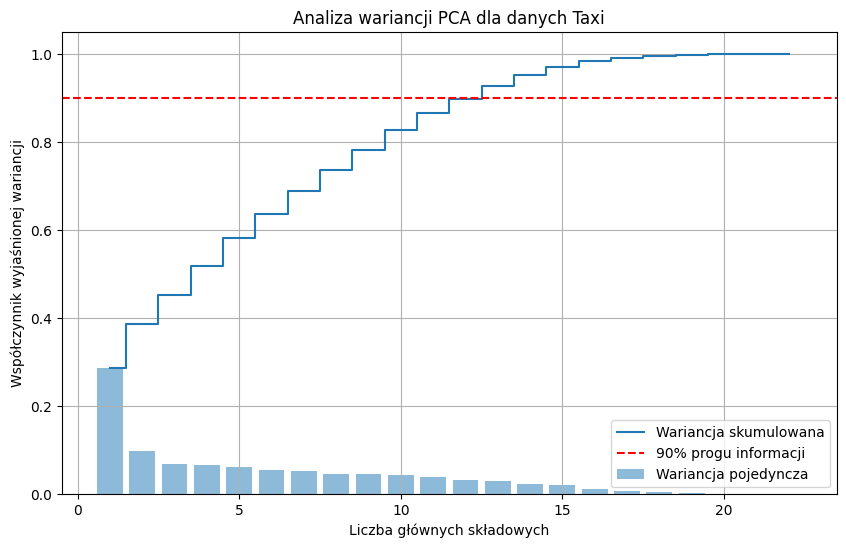

Liczba komponentów potrzebna do 90% wariancji: 13


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Inicjalizacja PCA
pca_full = PCA()
pca_full.fit(X_scaled)

# Obliczanie skumulowanej wariancji
cum_explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

# wykres osypiska
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(cum_explained_variance) + 1), pca_full.explained_variance_ratio_,
        alpha=0.5, align='center', label='Wariancja pojedyncza')
plt.step(range(1, len(cum_explained_variance) + 1), cum_explained_variance,
         where='mid', label='Wariancja skumulowana')

plt.axhline(y=0.9, color='r', linestyle='--', label='90% progu informacji')
plt.ylabel('Współczynnik wyjaśnionej wariancji')
plt.xlabel('Liczba głównych składowych')
plt.title('Analiza wariancji PCA dla danych Taxi')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print(f"Liczba komponentów potrzebna do 90% wariancji: {np.argmax(cum_explained_variance >= 0.9) + 1}")

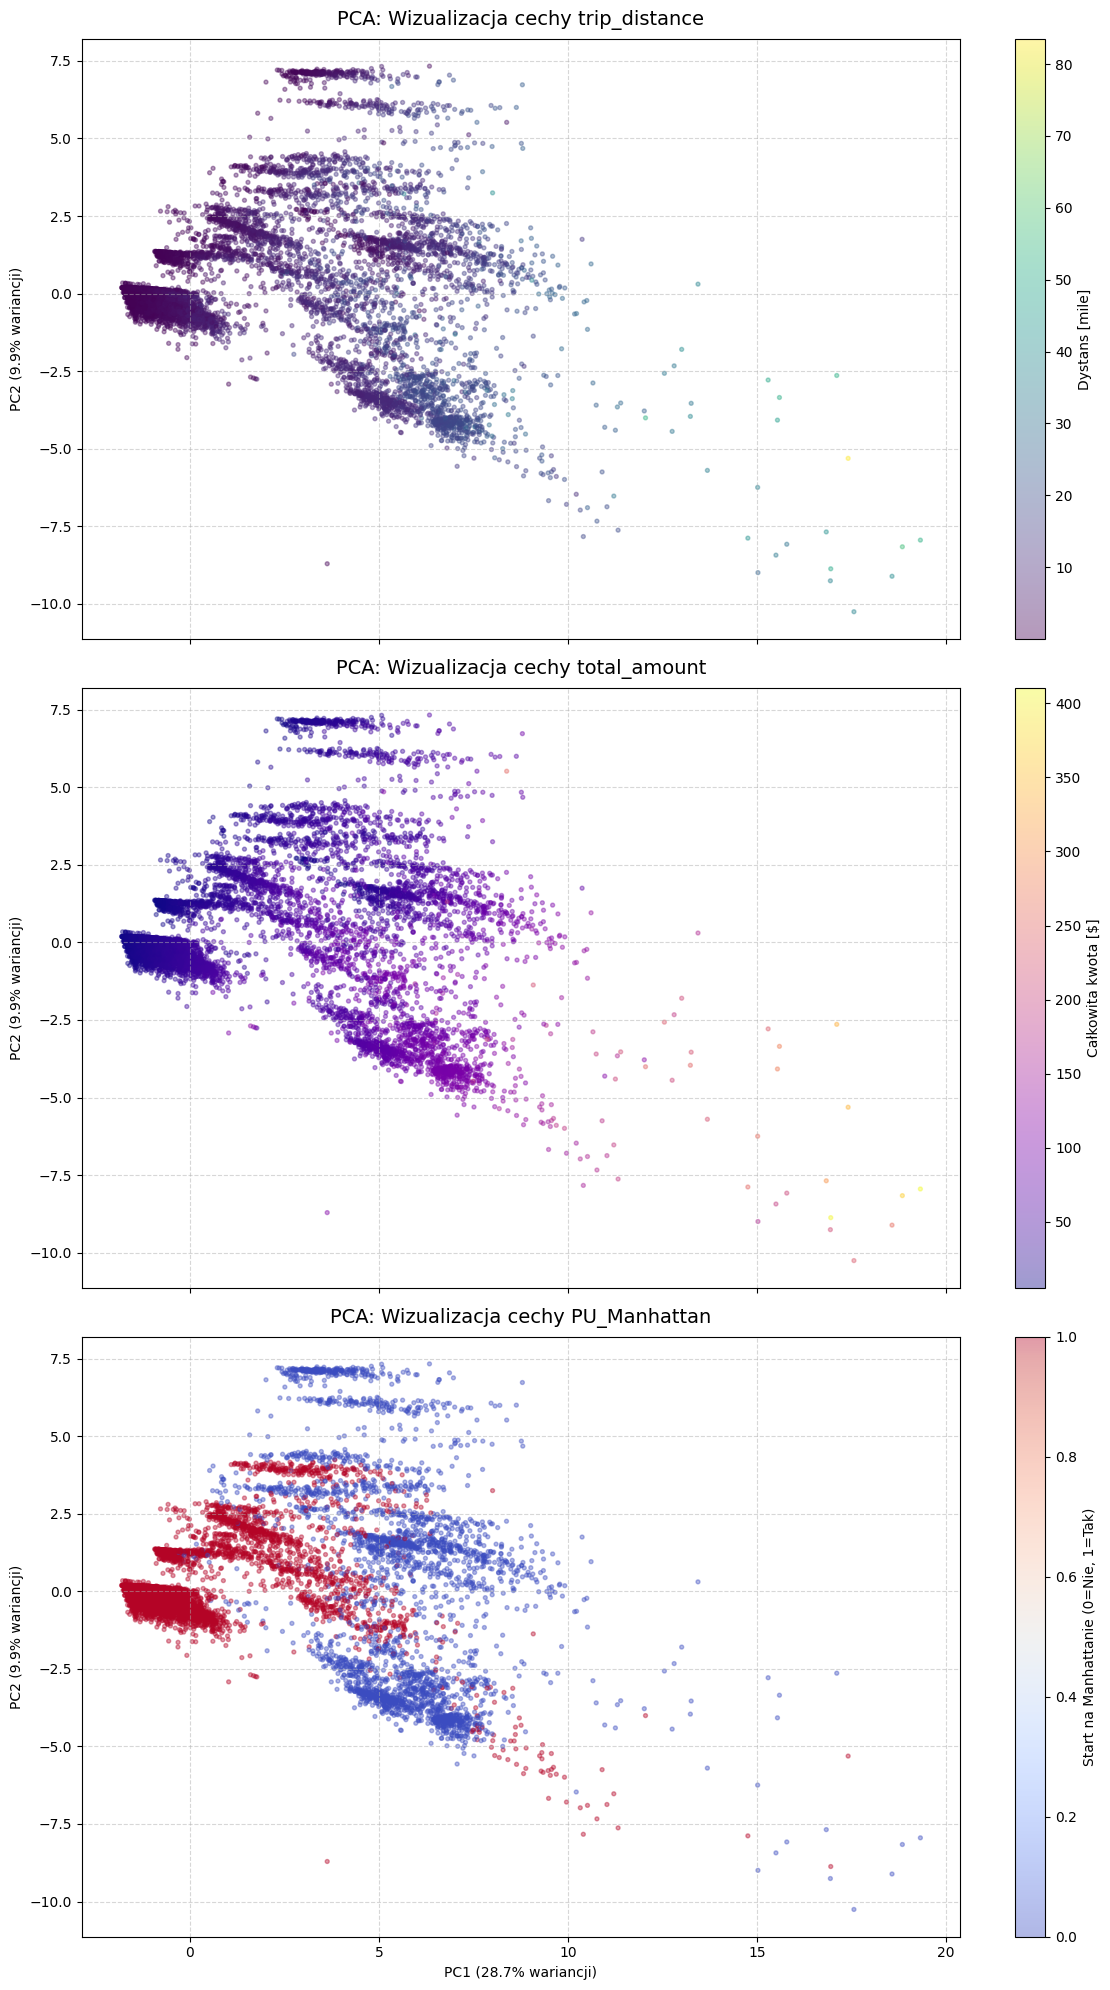

In [11]:
# Wykorzystujemy już dopasowany obiekt pca_full do transformacji danych
# Wybieramy tylko pierwsze dwa komponenty [:, :2]
X_pca_array = pca_full.transform(X_scaled)[:, :2]

# Tworzymy DataFrame wynikowy zachowując indeksy z df_sample
df_pca = pd.DataFrame(
    data=X_pca_array,
    columns=['PC1', 'PC2'],
    index=X_scaled.index
)

# Dołączamy kolumny z df_sample do kolorowania punktów
cols_to_color = ['trip_distance', 'total_amount', 'PU_Manhattan']
df_plot = df_pca.join(df_sample[cols_to_color])

# Pobieramy dokładne wartości wariancji z pca_full do etykiet osi
var_pc1 = pca_full.explained_variance_ratio_[0] * 100
var_pc2 = pca_full.explained_variance_ratio_[1] * 100

# Generowanie trzech wykresów w układzie pionowym
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 20), sharex=True, sharey=True)

configs = [
    {'col': 'trip_distance', 'label': 'Dystans [mile]', 'cmap': 'viridis'},
    {'col': 'total_amount', 'label': 'Całkowita kwota [$]', 'cmap': 'plasma'},
    {'col': 'PU_Manhattan', 'label': 'Start na Manhattanie (0=Nie, 1=Tak)', 'cmap': 'coolwarm'}
]

for i, ax in enumerate(axes):
    conf = configs[i]

    # Rysowanie punktów
    scatter = ax.scatter(
        df_plot['PC1'],
        df_plot['PC2'],
        c=df_plot[conf['col']],
        cmap=conf['cmap'],
        alpha=0.4,
        s=8
    )

    # Dodanie paska skali (colorbar)
    plt.colorbar(scatter, ax=ax, label=conf['label'])

    # Opisy i siatka
    ax.set_title(f"PCA: Wizualizacja cechy {conf['col']}", fontsize=14, pad=10)
    ax.set_ylabel(f'PC2 ({var_pc2:.1f}% wariancji)')
    ax.grid(True, linestyle='--', alpha=0.5)

# Wspólna etykieta osi X na samym dole
axes[2].set_xlabel(f'PC1 ({var_pc1:.1f}% wariancji)')

plt.tight_layout()
plt.show()

## Te same wykresy, ale z zastosowaniem kilku zmian, by można lepiej zauważyć zmienność na podstawie trzech cech (trip_distance, total_amount, PU_Manhattan)

1. Wybór kontrastowych map kolorów

2. Wyświetlanie punktów o wyższych wartościach na wierzchu.

3. Skalowanie logarytmiczne: Zastosowanie LogNorm dla finansów i dystansu, ponieważ większość kursów jest krótka i tania, co powoduje kumulację jednego koloru.

4. Regulacja przezroczystości i rozmiaru

5. Mapy rozbieżne dla zmiennych binarnych

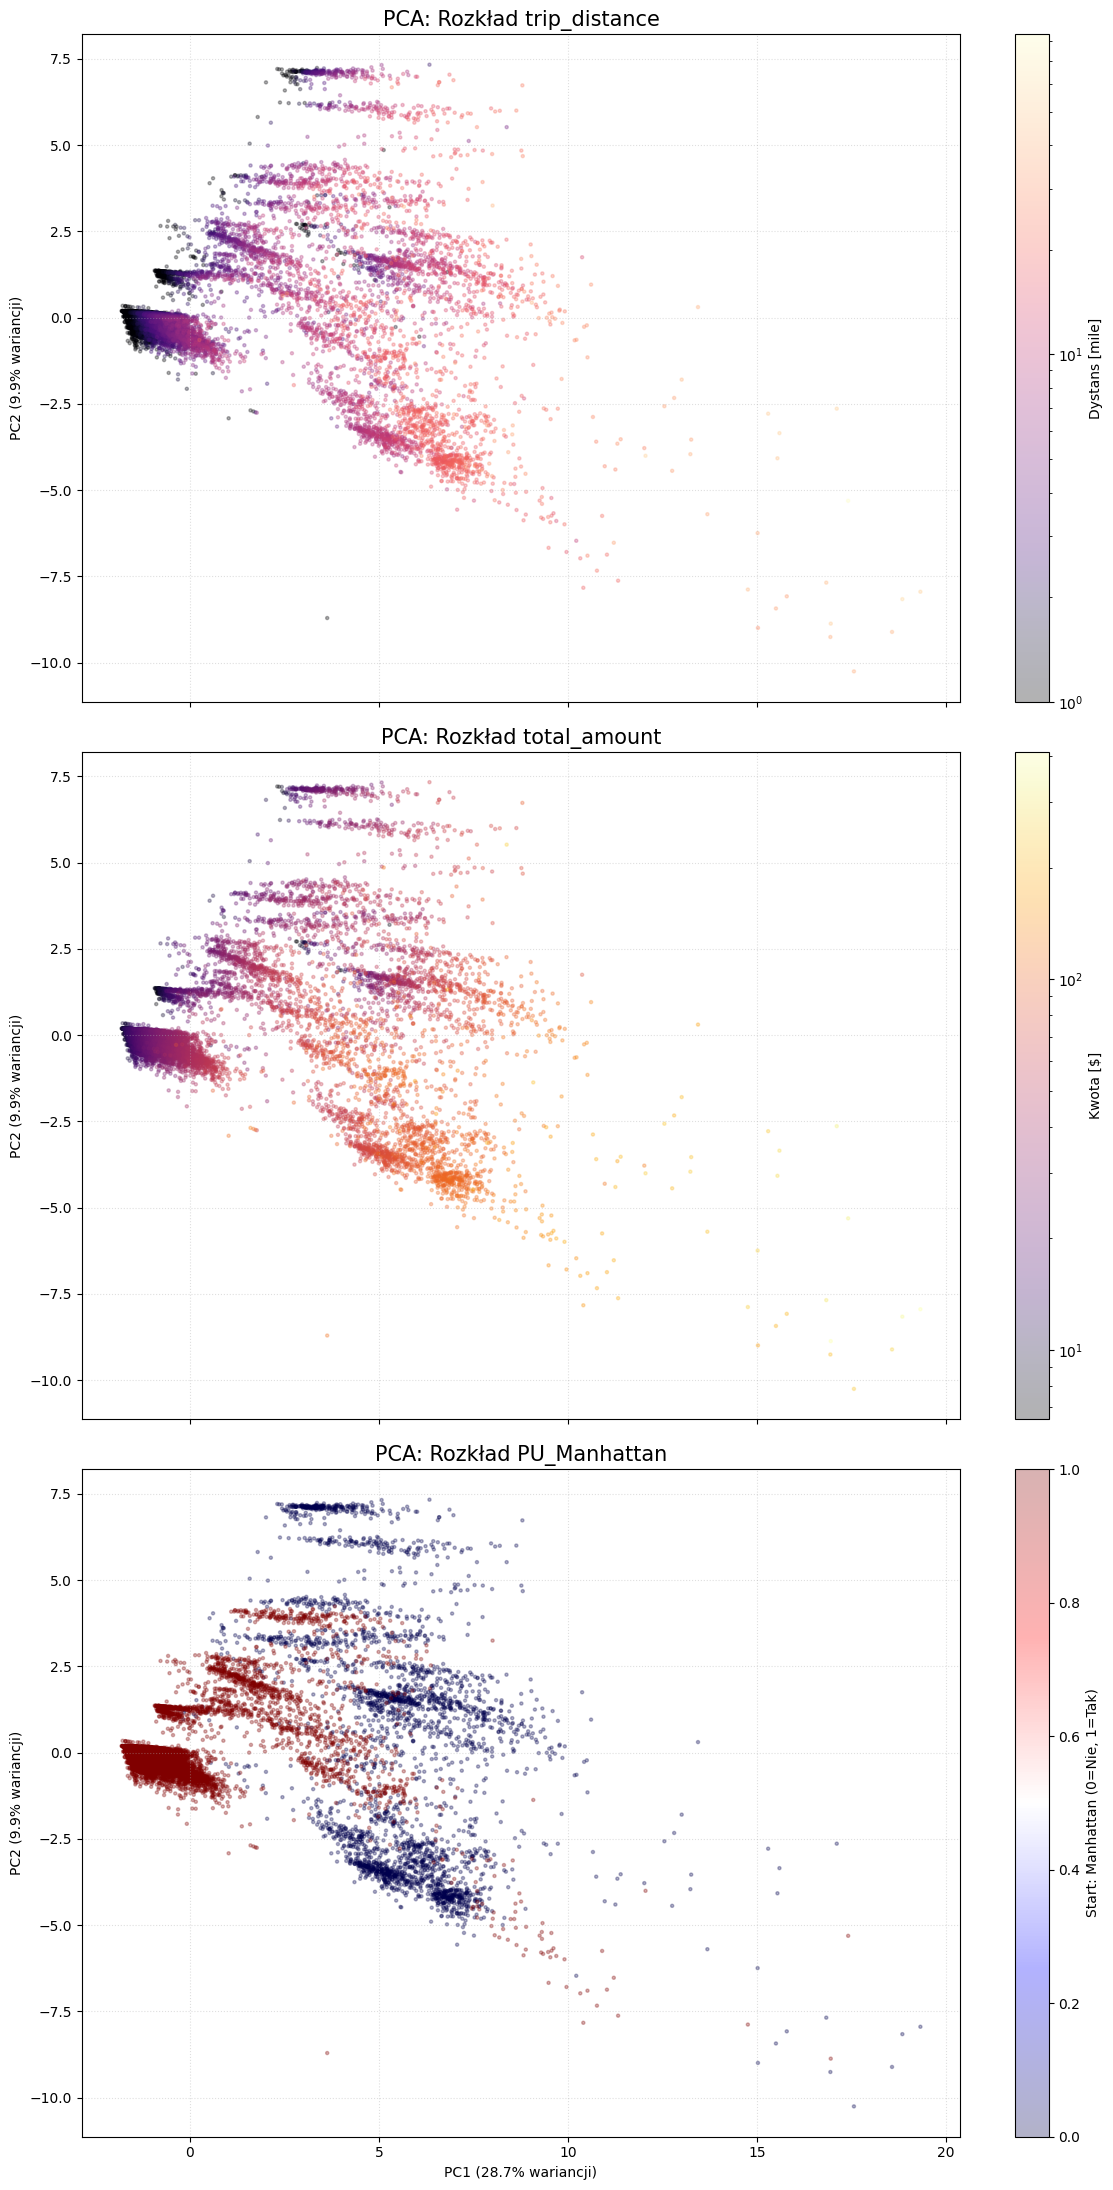

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

X_pca_array = pca_full.transform(X_scaled)[:, :2]
df_pca = pd.DataFrame(X_pca_array, columns=['PC1', 'PC2'], index=X_scaled.index)
cols_to_color = ['trip_distance', 'total_amount', 'PU_Manhattan']
df_plot = df_pca.join(df_sample[cols_to_color])

var_pc1 = pca_full.explained_variance_ratio_[0] * 100
var_pc2 = pca_full.explained_variance_ratio_[1] * 100

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 22), sharex=True, sharey=True)

configs = [
    {
        'col': 'trip_distance',
        'label': 'Dystans [mile]',
        'cmap': 'magma',
        'norm': mcolors.LogNorm(vmin=1, vmax=df_plot['trip_distance'].max())
    },
    {
        'col': 'total_amount',
        'label': 'Kwota [$]',
        'cmap': 'inferno',
        'norm': mcolors.LogNorm(vmin=df_plot['total_amount'].min() + 1, vmax=df_plot['total_amount'].max())
    },
    {
        'col': 'PU_Manhattan',
        'label': 'Start: Manhattan (0=Nie, 1=Tak)',
        'cmap': 'seismic',
        'norm': None
    }
]

for i, ax in enumerate(axes):
    conf = configs[i]

    # Sortowanie, aby wyższe/istotne wartości były rysowane na końcu (na wierzchu)
    df_sorted = df_plot.sort_values(by=conf['col'])

    scatter = ax.scatter(
        df_sorted['PC1'],
        df_sorted['PC2'],
        c=df_sorted[conf['col']],
        cmap=conf['cmap'],
        norm=conf['norm'],
        alpha=0.3,
        s=5
    )

    plt.colorbar(scatter, ax=ax, label=conf['label'])
    ax.set_title(f"PCA: Rozkład {conf['col']}", fontsize=15)
    ax.set_ylabel(f'PC2 ({var_pc2:.1f}% wariancji)')
    ax.grid(True, linestyle=':', alpha=0.4)

axes[2].set_xlabel(f'PC1 ({var_pc1:.1f}% wariancji)')
plt.tight_layout()
plt.show()

In [13]:
# Sprawdzamy, które cechy najbardziej wpływają na PC1 i PC2
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)
print("--- WPŁYW CECH NA KOMPONENTY (LOADINGS) ---")
display(loadings.sort_values(by='PC1', ascending=False))

--- WPŁYW CECH NA KOMPONENTY (LOADINGS) ---


,PC1,PC2
trip_distance,3.686314e-01,-0.102750
fare_amount,3.616987e-01,-0.128122
PU_Queens,3.222256e-01,-0.184465
duration,3.094799e-01,0.064695
Airport_fee,3.072292e-01,-0.218788
tolls_amount,2.555015e-01,-0.285197
tip_amount,2.128245e-01,-0.360458
DO_Queens,1.611229e-01,0.141379
DO_Brooklyn,1.565115e-01,0.349893
PU_Brooklyn,9.434984e-02,0.417223


In [14]:
# Przykład: znajdźmy kursy o ekstremalnie wysokim PC1
anomalies_pc1 = df_pca.nlargest(5, 'PC1')
display(df_sample.loc[anomalies_pc1.index])

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,...,PU_Queens,PU_Staten Island,PU_Unknown,DO_Bronx,DO_Brooklyn,DO_EWR,DO_Manhattan,DO_Queens,DO_Staten Island,DO_Unknown
1383075,2026-03-15 16:33:17,2026-03-15 17:49:07,4,52.169998,5,1,350.000000,50.000000,7.460000,410.459991,...,1,0,0,0,0,0,0,0,0,0
2251377,2026-03-24 22:26:22,2026-03-24 23:33:12,1,56.869999,4,1,289.299988,60.849998,7.460000,367.109985,...,1,0,0,0,0,0,0,0,0,0
2706638,2026-03-29 19:30:40,2026-03-29 20:36:57,1,39.580002,4,1,184.300003,10.000000,60.500000,257.799988,...,1,0,0,0,0,0,0,0,0,0
1092167,2026-03-12 18:45:52,2026-03-12 19:56:56,1,36.680000,4,1,157.000000,38.439999,31.709999,232.399994,...,1,0,0,0,0,1,0,0,0,0
579733,2026-03-07 10:00:30,2026-03-07 11:36:42,2,83.500000,1,1,299.100006,25.000000,14.790000,340.640015,...,0,0,0,0,0,0,0,0,0,0


### Wnioski:

Wykres charakteryzuje się wyraźną pasiastą strukturą, co jest zjawiskiem typowym w przypadku zbiorów danych zawierających liczne kolumny powstałe w wyniku kodowania One-Hot Encoding.

Największe zagęszczenie punktów występuje w okolicach wartości 0 na osi X. Im dalej w prawą stronę tej osi, tym liczba obserwowanych punktów staje się mniejsza. Zjawisko to wynika z faktu, że zdecydowana większość kursów to przejazdy krótkie i o niskiej opłacie. Analiza oddziaływania poszczególnych zmiennych na składową PC1 pokazuje, że największy wpływ na jej wartości mają cechy takie jak: trip_distance, fare_amount oraz duration.

Na oś Y wpływają przede wszystkim dzielnice rozpoczęcia oraz zakończenia kursu (PU/DO Boroughs), co znajduje bezpośrednie odzwierciedlenie w widocznej, pasiastej strukturze wizualizacji.

Z analizy pięciu najbardziej odległych na osi X przejazdów wynika, że były one ekstremalnie długie, odległe i drogie, co jest zgodne z intuicją.